# Lactococcus variant calling pipeline

A complete NGS pipeline: from raw reads (FASTQ) on SRA to called variants (VCF),
followed by visualization and a deeper look into a coverage anomaly.

**Reference:** `GCF_003176835.1` (Lactococcus lactis subsp. lactis, assembly ASM317683v1)
**Sample:** `SRR39660835` (Lactococcus cremoris isolate, paired-end Illumina reads)

**Pipeline:** FASTQ -> BWA (alignment) -> SAM -> BAM -> bcftools (variant calling) -> VCF -> visualization


## 1. Install tools

SRA Toolkit (download reads), NCBI Datasets CLI (download reference), BWA, samtools, bcftools.

In [1]:
# --- SRA Toolkit: for downloading raw reads (FASTQ) from the SRA archive ---
!wget --quiet https://ftp-trace.ncbi.nlm.nih.gov/sra/sdk/current/sratoolkit.current-ubuntu64.tar.gz
!tar -xzf sratoolkit.current-ubuntu64.tar.gz
!mv sratoolkit.*-ubuntu64 sratoolkit

import os
# Add SRA Toolkit to PATH so its commands (prefetch, fasterq-dump) are directly callable
os.environ['PATH'] += os.pathsep + '/content/sratoolkit/bin'

# --- NCBI Datasets CLI: for downloading the reference genome + annotation (GFF) ---
!wget -q https://ftp.ncbi.nlm.nih.gov/pub/datasets/command-line/v2/linux-amd64/datasets
!chmod +x datasets

# --- Tools for alignment and variant calling ---
!apt-get install -y bwa samtools bcftools -qq


Selecting previously unselected package libhtscodecs2:amd64.
(Reading database ... 118332 files and directories currently installed.)
Preparing to unpack .../libhtscodecs2_1.1.1-3_amd64.deb ...
Unpacking libhtscodecs2:amd64 (1.1.1-3) ...
Selecting previously unselected package libhts3:amd64.
Preparing to unpack .../libhts3_1.13+ds-2build1_amd64.deb ...
Unpacking libhts3:amd64 (1.13+ds-2build1) ...
Selecting previously unselected package bcftools.
Preparing to unpack .../bcftools_1.13-1_amd64.deb ...
Unpacking bcftools (1.13-1) ...
Selecting previously unselected package bwa.
Preparing to unpack .../bwa_0.7.17-6_amd64.deb ...
Unpacking bwa (0.7.17-6) ...
Selecting previously unselected package samtools.
Preparing to unpack .../samtools_1.13-4_amd64.deb ...
Unpacking samtools (1.13-4) ...
Setting up libhtscodecs2:amd64 (1.1.1-3) ...
Setting up libhts3:amd64 (1.13+ds-2build1) ...
Setting up bwa (0.7.17-6) ...
Setting up bcftools (1.13-1) ...
Setting up samtools (1.13-4) ...
Processing tri

## 2. Reference genome

Download the reference plus its GFF3 annotation in one call - the annotation will be
useful later, when we look into which genes sit in the problematic regions of the genome.

Index the reference with `bwa index` (needed for alignment) and `samtools faidx`
(needed for variant calling in a later step).


In [2]:
# --include genome,gff3 pulls both the FASTA and the gene annotation in one request
!./datasets download genome accession GCF_003176835.1 --include genome,gff3
!unzip -o ncbi_dataset.zip -d ncbi_dataset

# Find the real file paths automatically instead of hardcoding them -
# NCBI Datasets nests files deep inside folders with long generated names
import subprocess

REF = subprocess.check_output(
    "find ncbi_dataset -iname '*_genomic.fna'", shell=True
).decode().strip()

GFF = subprocess.check_output(
    "find ncbi_dataset -iname 'genomic.gff'", shell=True
).decode().strip()

print("Reference FASTA:", REF)
print("Reference GFF:  ", GFF)


Downloading: ncbi_dataset.zip    847B 11.3MB/s
Downloading: ncbi_dataset.zip    847B 11.3MB/s
Downloading: ncbi_dataset.zip    2.72kB 134kB/s
Downloading: ncbi_dataset.zip    2.72kB 134kB/s
Downloading: ncbi_dataset.zip    2.72kB 134kB/s
Downloading: ncbi_dataset.zip    2.72kB 134kB/s
Downloading: ncbi_dataset.zip    3.86kB 61.8kB/s
Downloading: ncbi_dataset.zip    3.86kB 61.8kB/s
Downloading: ncbi_dataset.zip    32.8kB 428kB/s
Downloading: ncbi_dataset.zip    65.5kB 726kB/s
Downloading: ncbi_dataset.zip    197kB 1.88MB/s
Downloading: ncbi_dataset.zip    229kB 1.96MB/s
Downloading: ncbi_dataset.zip    426kB 3.39MB/s
Downloading: ncbi_dataset.zip    819kB 5.91MB/s
Downloading: ncbi_dataset.zip    1.02MB done
Validating package files [==============>---------------------------------]  33% 2/6
Downloading: ncbi_dataset.zip    1.02MB done
Validating package files [==============>---------------------------------]  33% 2/6
Downloading: ncbi_dataset.zip    1.02MB done
Validating package file

In [3]:
# Index the reference for BWA (one-time step, creates .amb/.ann/.bwt/.pac/.sa)
!bwa index {REF}

# Index for samtools (creates .fai - fast coordinate lookup, required by bcftools)
!samtools faidx {REF}


[bwa_index] Pack FASTA... 0.02 sec
[bwa_index] Construct BWT for the packed sequence...
[bwa_index] 0.65 seconds elapse.
[bwa_index] Update BWT... 0.02 sec
[bwa_index] Pack forward-only FASTA... 0.01 sec
[bwa_index] Construct SA from BWT and Occ... 0.35 sec
[main] Version: 0.7.17-r1188
[main] CMD: bwa index ncbi_dataset/ncbi_dataset/data/GCF_003176835.1/GCF_003176835.1_ASM317683v1_genomic.fna
[main] Real time: 1.118 sec; CPU: 1.049 sec


## 3. Sample reads (FASTQ)

Download and convert the reads for the isolate of interest from SRA.
`--split-files` is required for paired-end data - otherwise R1/R2 get merged into one
file and the alignment loses the paired-read information.


In [4]:
!prefetch SRR39660835
!fasterq-dump SRR39660835 --split-files -O /content/fastq_output

R1 = "/content/fastq_output/SRR39660835_1.fastq"
R2 = "/content/fastq_output/SRR39660835_2.fastq"


2026-08-14T01:11:52 prefetch.3.4.1: 1) Resolving 'SRR39660835'...
2026-08-14T01:11:52 prefetch.3.4.1: Current preference is set to retrieve SRA Normalized Format files with full base quality scores
2026-08-14T01:11:52 prefetch.3.4.1: 1) Downloading 'SRR39660835'...
2026-08-14T01:11:52 prefetch.3.4.1:  SRA Normalized Format file is being retrieved
2026-08-14T01:11:52 prefetch.3.4.1:  Downloading via HTTPS...
2026-08-14T01:12:05 prefetch.3.4.1:  HTTPS download succeed
2026-08-14T01:12:06 prefetch.3.4.1:  'SRR39660835' is valid: 339075945 bytes were streamed from 339065396
2026-08-14T01:12:06 prefetch.3.4.1: 1) 'SRR39660835' was downloaded successfully
2026-08-14T01:12:06 prefetch.3.4.1: 1) Resolving 'SRR39660835's dependencies...
2026-08-14T01:12:06 prefetch.3.4.1: 'SRR39660835' has 0 unresolved dependencies
spots read      : 3,454,734
reads read      : 6,909,468
reads written   : 6,909,468


## 4. Alignment

`bwa mem` is the standard BWA algorithm for reads >70bp (fits Illumina data).
Passing both R1 and R2 lets BWA use paired-read information, which improves
alignment accuracy in repetitive or otherwise tricky regions of the genome.


In [5]:
!bwa mem {REF} {R1} {R2} > aligned.sam

[M::bwa_idx_load_from_disk] read 0 ALT contigs
[M::process] read 79048 sequences (10000226 bp)...
[M::process] read 79326 sequences (10000144 bp)...
[M::mem_pestat] # candidate unique pairs for (FF, FR, RF, RR): (3, 17331, 4, 2)
[M::mem_pestat] skip orientation FF as there are not enough pairs
[M::mem_pestat] analyzing insert size distribution for orientation FR...
[M::mem_pestat] (25, 50, 75) percentile: (108, 186, 279)
[M::mem_pestat] low and high boundaries for computing mean and std.dev: (1, 621)
[M::mem_pestat] mean and std.dev: (199.48, 110.58)
[M::mem_pestat] low and high boundaries for proper pairs: (1, 792)
[M::mem_pestat] skip orientation RF as there are not enough pairs
[M::mem_pestat] skip orientation RR as there are not enough pairs
[M::mem_process_seqs] Processed 79048 reads in 10.912 CPU sec, 10.958 real sec
[M::process] read 79870 sequences (10000200 bp)...
[M::mem_pestat] # candidate unique pairs for (FF, FR, RF, RR): (4, 17177, 5, 2)
[M::mem_pestat] skip orientation F

## 5. SAM -> BAM

Convert the text-based SAM into a compact binary BAM, sort it by coordinate
(required for variant calling and indexing), and build an index for fast access.


In [6]:
!samtools view -bS aligned.sam > aligned.bam   # text SAM -> binary BAM
!samtools sort aligned.bam -o sorted.bam        # sort by genomic position
!samtools index sorted.bam                       # index for fast random access


[bam_sort_core] merging from 2 files and 1 in-memory blocks...


## 6. Variant calling

`bcftools mpileup` computes per-position coverage statistics, `bcftools call`
determines where the differences from the reference are statistically significant.

**Note:** `--ploidy 1` - Lactococcus is haploid, unlike diploid eukaryotes. Without this
flag bcftools assumes a diploid organism by default and can misinterpret
heterozygosity in a place where it can't physically exist.


In [7]:
!bcftools mpileup -f {REF} sorted.bam | bcftools call -mv --ploidy 1 -Oz -o variants.vcf.gz

[mpileup] 1 samples in 1 input files
[mpileup] maximum number of reads per input file set to -d 250


## 7. Results: stats and a first look at the variants

In [8]:
!bcftools stats variants.vcf.gz | grep -E "number of SNPs|number of indels|ts/tv"


#   number of SNPs      .. number of rows with a SNP
#   number of indels    .. number of rows with an indel
SN	0	number of SNPs:	159281
SN	0	number of indels:	792
# TSTV	[2]id	[3]ts	[4]tv	[5]ts/tv	[6]ts (1st ALT)	[7]tv (1st ALT)	[8]ts/tv (1st ALT)
# SiS	[2]id	[3]allele count	[4]number of SNPs	[5]number of transitions	[6]number of transversions	[7]number of indels	[8]repeat-consistent	[9]repeat-inconsistent	[10]not applicable
# AF	[2]id	[3]allele frequency	[4]number of SNPs	[5]number of transitions	[6]number of transversions	[7]number of indels	[8]repeat-consistent	[9]repeat-inconsistent	[10]not applicable
# QUAL	[2]id	[3]Quality	[4]number of SNPs	[5]number of transitions (1st ALT)	[6]number of transversions (1st ALT)	[7]number of indels


In [9]:
# Save the VCF without the header lines (##...) to a plain tsv for analysis in pandas
!zcat variants.vcf.gz | grep -v "^##" > all_variants.tsv

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("all_variants.tsv", sep="\t")
df = df.rename(columns={"#CHROM": "CHROM"})
df.head()


,CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO,FORMAT,sorted.bam
0,NZ_CP028160.1,311,.,T,C,36.4154,.,DP=3;VDB=0.1;SGB=-0.453602;FS=0;MQ0F=0;AC=1;AN...,GT:PL,"1:66,0"
1,NZ_CP028160.1,415,.,T,C,219.4170,.,DP=10;VDB=1.19856e-05;SGB=-0.662043;FS=0;MQ0F=...,GT:PL,"1:249,0"
2,NZ_CP028160.1,427,.,A,G,225.4170,.,DP=183;VDB=0;SGB=-0.693147;MQSBZ=0.96222;FS=0;...,GT:PL,"1:255,0"
3,NZ_CP028160.1,431,.,C,G,225.4170,.,DP=187;VDB=5.64962e-41;SGB=-0.693147;MQSBZ=0.9...,GT:PL,"1:255,0"
4,NZ_CP028160.1,450,.,G,A,225.4220,.,DP=215;VDB=1.80281e-21;SGB=-0.693147;FS=0;MQ0F...,GT:PL,"1:255,0"


## 8. Visualization: variant distribution across the genome

The scatter plot shows each variant's position (x-axis) against its confidence
score - QUAL (y-axis). QUAL ~225 is effectively the ceiling of the scale (maximum
confidence); variants with a low QUAL are less reliable.


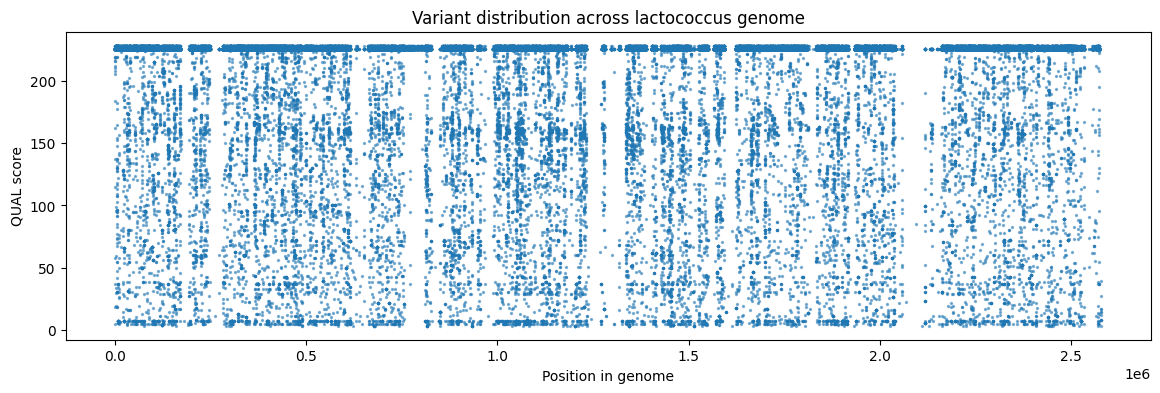

In [17]:
plt.figure(figsize=(14,4))
plt.scatter(df["POS"], df["QUAL"], s=2, alpha=0.5)
plt.xlabel("Position in genome")
plt.ylabel("QUAL score")
plt.title("Variant distribution across lactococcus genome")
plt.show()


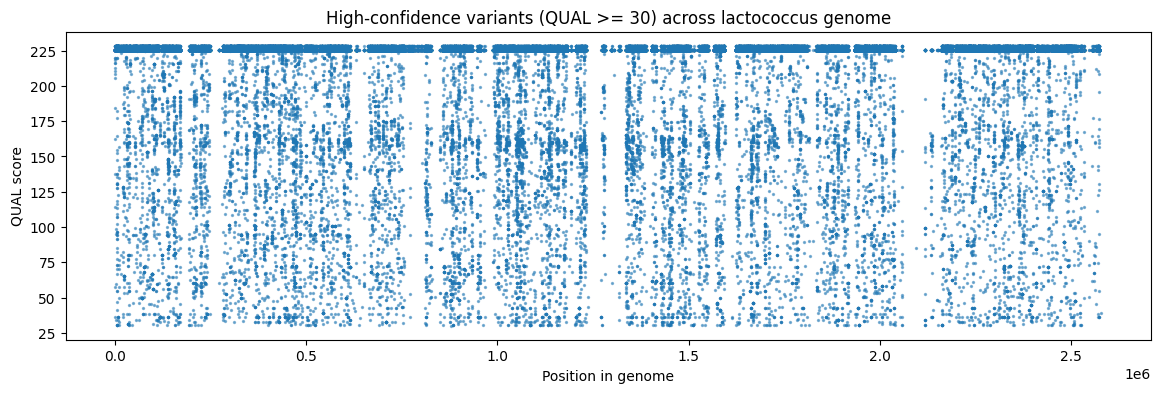

In [18]:
# Keep only high-confidence variants (QUAL >= 30 is a standard filtering threshold)
df_filtered = df[df["QUAL"] >= 30]

plt.figure(figsize=(14,4))
plt.scatter(df_filtered["POS"], df_filtered["QUAL"], s=2, alpha=0.5)
plt.xlabel("Position in genome")
plt.ylabel("QUAL score")
plt.title("High-confidence variants (QUAL >= 30) across lactococcus genome")
plt.show()


## 9. Investigating an anomaly: near-empty regions on the plot

The variant plot shows stretches with almost no variants (e.g. ~700-750 kb). There
are two possible explanations: (a) genuine biological conservation of the genes in
that region, (b) a technical artifact - reads simply couldn't map there confidently.
Both hypotheses are checked in turn below.


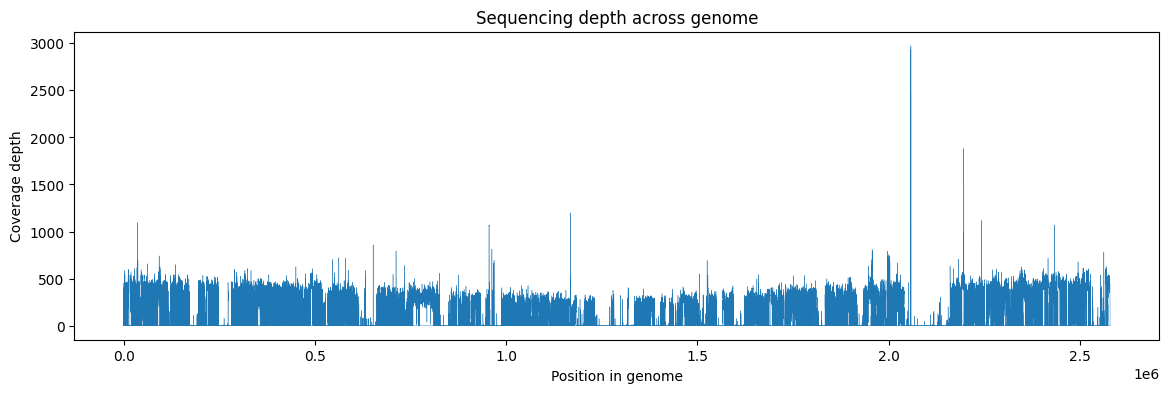

In [12]:
# Coverage (depth) across the whole genome - how many reads span each position
!samtools depth -a sorted.bam > coverage.txt

cov = pd.read_csv("coverage.txt", sep="\t", header=None, names=["CHROM", "POS", "DEPTH"])

plt.figure(figsize=(14,4))
plt.plot(cov["POS"], cov["DEPTH"], linewidth=0.3)
plt.xlabel("Position in genome")
plt.ylabel("Coverage depth")
plt.title("Sequencing depth across genome")
plt.show()


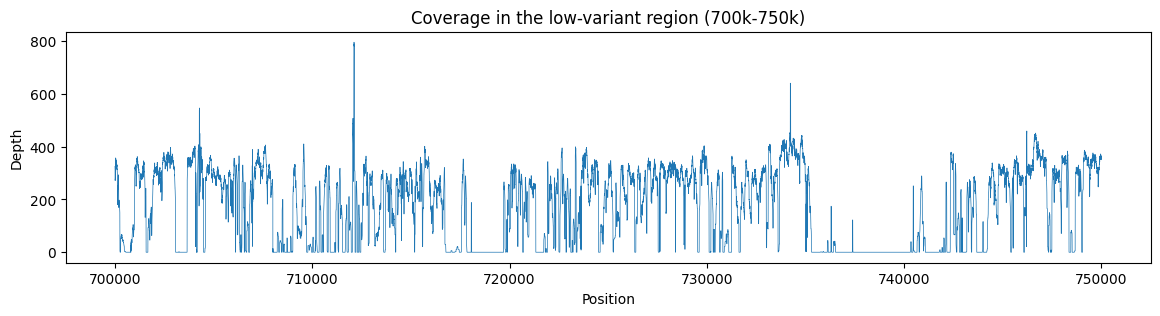

In [13]:
# Zoom into the specific problem region 700k-750k
cov_region = cov[(cov["POS"] >= 700000) & (cov["POS"] <= 750000)]

plt.figure(figsize=(14,3))
plt.plot(cov_region["POS"], cov_region["DEPTH"], linewidth=0.5)
plt.xlabel("Position")
plt.ylabel("Depth")
plt.title("Coverage in the low-variant region (700k-750k)")
plt.show()

# Takeaway: coverage repeatedly drops to zero in several narrow spots within the
# range - this already points to a technical cause (reads failing to map), not biology


### Which genes sit in this region

Checking the annotation (GFF) for what's located at coordinates 700-750 kb.


In [14]:
!awk -F'\t' '$3 == "gene" && $4 <= 750000 && $5 >= 700000' {GFF} | head -20

NZ_CP028160.1	RefSeq	gene	699588	700697	.	+	.	ID=gene-LL14B4_RS03505;Dbxref=GeneID:89632853;Name=LL14B4_RS03505;gbkey=Gene;gene_biotype=protein_coding;locus_tag=LL14B4_RS03505;old_locus_tag=LL14B4_03500
NZ_CP028160.1	RefSeq	gene	700823	701575	.	+	.	ID=gene-LL14B4_RS03510;Dbxref=GeneID:89632854;Name=LL14B4_RS03510;gbkey=Gene;gene_biotype=protein_coding;locus_tag=LL14B4_RS03510;old_locus_tag=LL14B4_03505
NZ_CP028160.1	RefSeq	gene	701563	702501	.	+	.	ID=gene-LL14B4_RS03515;Dbxref=GeneID:89632855;Name=LL14B4_RS03515;gbkey=Gene;gene_biotype=protein_coding;locus_tag=LL14B4_RS03515;old_locus_tag=LL14B4_03510
NZ_CP028160.1	RefSeq	gene	702502	702969	.	+	.	ID=gene-LL14B4_RS03520;Dbxref=GeneID:89632856;Name=tadA;gbkey=Gene;gene=tadA;gene_biotype=protein_coding;locus_tag=LL14B4_RS03520;old_locus_tag=LL14B4_03515
NZ_CP028160.1	RefSeq	gene	702985	703070	.	+	.	ID=gene-LL14B4_RS03525;Dbxref=GeneID:89632857;Name=ffs;gbkey=Gene;gene=ffs;gene_biotype=SRP_RNA;locus_tag=LL14B4_RS03525;old_locus_tag=LL14B4_

### Testing the hypothesis: mapping quality (MAPQ) in the problem region

First get the exact contig name from the BAM (needed for a region query), then look
at the MAPQ distribution of the reads that landed in this zone. A low MAPQ (0-6)
means a read maps equally well to several places in the genome, so BWA can't
confidently pick just one.


In [15]:
!samtools view -H sorted.bam | grep "^@SQ"


@SQ	SN:NZ_CP028160.1	LN:2579381
@SQ	SN:NZ_CP028161.1	LN:59700


In [16]:
# Plug in the exact contig name obtained in the previous cell
CONTIG = "NZ_CP028160.1"

!samtools view sorted.bam {CONTIG}:717000-720000 | awk '{{print $5}}' | sort | uniq -c


   1743 5


**Conclusion:** a large share of reads in this region have MAPQ 0 or 6 (hundreds of reads) - meaning BWA cannot confidently assign them to a single place in the genome. This is a classic signature of repetitive genomic elements - for example rRNA operons (Lactococcus lactis carries several nearly identical copies) or IS elements (mobile genetic elements present as many similar copies scattered across the genome).
So the near-empty regions in the variant plot are mostly a multi-mapping technical artifact, not a sign of biological conservation. One methodological detail worth noting: this issue comes from repeats within the reference genome itself, not from comparing the reference to the isolate - it would show up even when aligning L. lactis subsp. lactis reads back onto itself.
